<a href="https://colab.research.google.com/github/Sanathcharan/Data-Science-ExcelR/blob/main/KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('driver-data.csv')
df

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25
...,...,...,...
3995,3423310685,160.04,10
3996,3423312600,176.17,5
3997,3423312921,170.91,12
3998,3423313630,176.14,5


In [ ]:
df.shape

(4000, 3)

In [ ]:
df.size

12000

In [ ]:
df.isnull().sum()

,0
id,0
mean_dist_day,0
mean_over_speed_perc,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
feat=df.drop(columns='id')

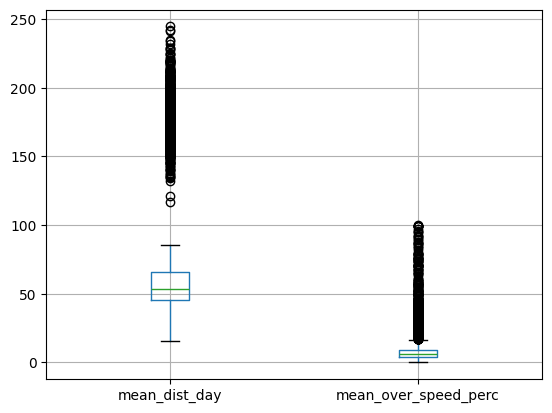

In [ ]:
feat.boxplot()
plt.show()

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  upper=q3+(1.5*iqr)
  lower=q1-(1.5*iqr)
  df[i]=df[i].clip(lower,upper)

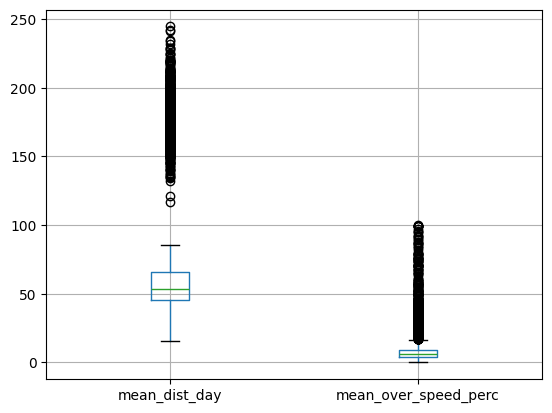

In [ ]:
feat.boxplot()
plt.show()

In [ ]:
df.drop(columns='id',inplace=True)
df

,mean_dist_day,mean_over_speed_perc
0,71.24,16.5
1,52.53,16.5
2,64.54,16.5
3,55.69,16.5
4,54.58,16.5
...,...,...
3995,96.21,10.0
3996,96.21,5.0
3997,96.21,12.0
3998,96.21,5.0


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df[['mean_dist_day','mean_over_speed_perc']]=sc.fit_transform(df[['mean_dist_day','mean_over_speed_perc']])
df

,mean_dist_day,mean_over_speed_perc
0,0.581561,1.876051
1,-0.328230,1.876051
2,0.255767,1.876051
3,-0.174572,1.876051
4,-0.228547,1.876051
...,...,...
3995,1.795751,0.515247
3996,1.795751,-0.531525
3997,1.795751,0.933956
3998,1.795751,-0.531525


In [ ]:
#making data to 3 clusters
from sklearn.cluster import KMeans
km=KMeans(n_clusters=3)
clusters=km.fit(df)
clusters.labels_

array([2, 2, 2, ..., 1, 1, 1], dtype=int32)

In [ ]:
np.unique(clusters.labels_)

array([0, 1, 2], dtype=int32)

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(df,clusters.labels_)

np.float64(0.6264505448525565)

In [ ]:
df1=pd.read_csv('driver-data.csv')
df1

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25
...,...,...,...
3995,3423310685,160.04,10
3996,3423312600,176.17,5
3997,3423312921,170.91,12
3998,3423313630,176.14,5


In [ ]:
df1['clusters']=clusters.labels_
df1

,id,mean_dist_day,mean_over_speed_perc,clusters
0,3423311935,71.24,28,2
1,3423313212,52.53,25,2
2,3423313724,64.54,27,2
3,3423311373,55.69,22,2
4,3423310999,54.58,25,2
...,...,...,...,...
3995,3423310685,160.04,10,1
3996,3423312600,176.17,5,1
3997,3423312921,170.91,12,1
3998,3423313630,176.14,5,1


In [ ]:
df1[df1['clusters']==1]

,id,mean_dist_day,mean_over_speed_perc,clusters
48,3423310944,81.34,31,1
216,3423310869,81.96,27,1
478,3423312793,85.36,17,1
995,3423313064,75.54,7,1
1288,3423311561,77.82,9,1
...,...,...,...,...
3995,3423310685,160.04,10,1
3996,3423312600,176.17,5,1
3997,3423312921,170.91,12,1
3998,3423313630,176.14,5,1


In [ ]:
df1[df1['clusters']==2]

,id,mean_dist_day,mean_over_speed_perc,clusters
0,3423311935,71.24,28,2
1,3423313212,52.53,25,2
2,3423313724,64.54,27,2
3,3423311373,55.69,22,2
4,3423310999,54.58,25,2
...,...,...,...,...
2728,3423312134,58.07,11,2
2978,3423313309,52.43,11,2
3060,3423310544,49.65,11,2
3106,3423310832,45.03,11,2


In [ ]:
df1[df1['clusters']==0]

,id,mean_dist_day,mean_over_speed_perc,clusters
5,3423313857,41.91,10,0
7,3423311434,52.02,8,0
58,3423310548,58.97,6,0
71,3423310765,49.86,10,0
91,3423311628,51.46,9,0
...,...,...,...,...
3195,3423312761,47.56,5,0
3196,3423314346,39.39,8,0
3197,3423313451,46.85,7,0
3198,3423313552,37.68,7,0


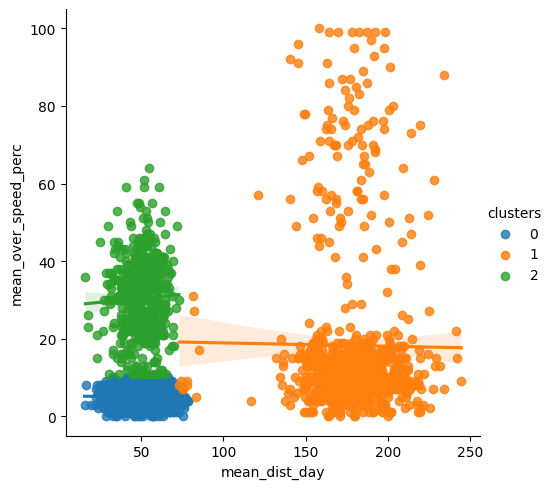

In [ ]:
# linearmodel plot
sns.lmplot(data=df1,x='mean_dist_day',y='mean_over_speed_perc',hue='clusters')
plt.show()

In [ ]:
# centroid
clusters.cluster_centers_

array([[-0.4547909 , -0.52358235],
       [ 1.78520516,  0.69345712],
       [-0.44475554,  1.81015959]])

In [ ]:
clusters.inertia_

2072.826562687574

In [ ]:
inertia=[]
for i in range(1,11):
  km=KMeans(n_clusters=i)
  km.fit(df)
  inertia.append(km.inertia_)
print(inertia)

[8000.00000000011, 3850.6091990466853, 2072.826562687574, 1628.7237025910508, 1061.0799761137293, 859.0778033570292, 715.750354758533, 613.7078372957537, 591.9554011888761, 468.8994245085413]


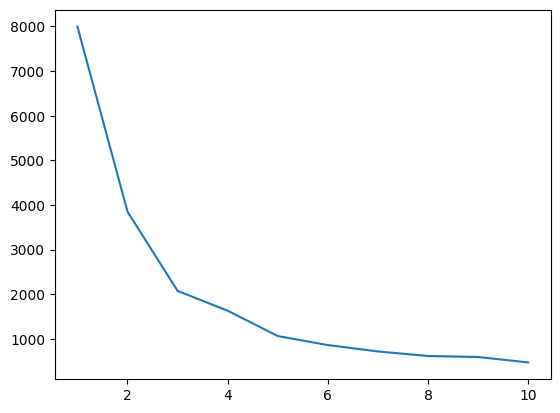

In [ ]:
# elbow method
plt.plot(range(1,11),inertia)
plt.show()

In [ ]:
! pip install yellowbrick

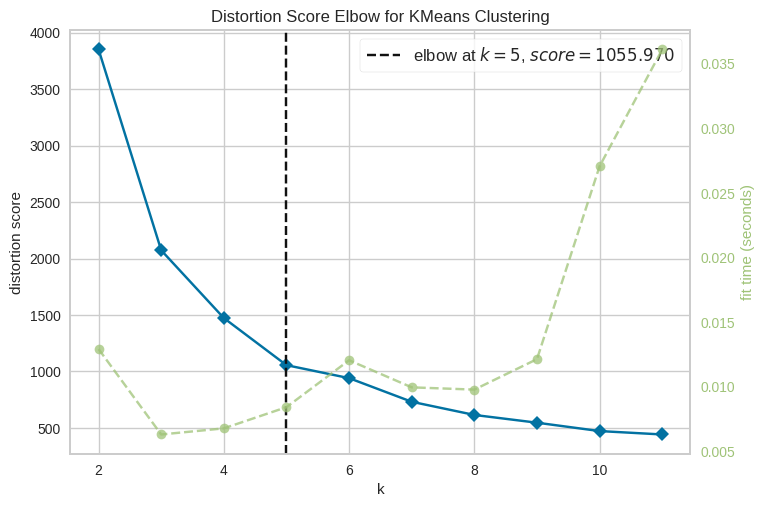

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn import metrics
from yellowbrick.cluster import KElbowVisualizer
visualizer=KElbowVisualizer(estimator=KMeans(),k=(2,12),metrcic='distortion',force_model=True)
visualizer.fit(df)
visualizer.show()

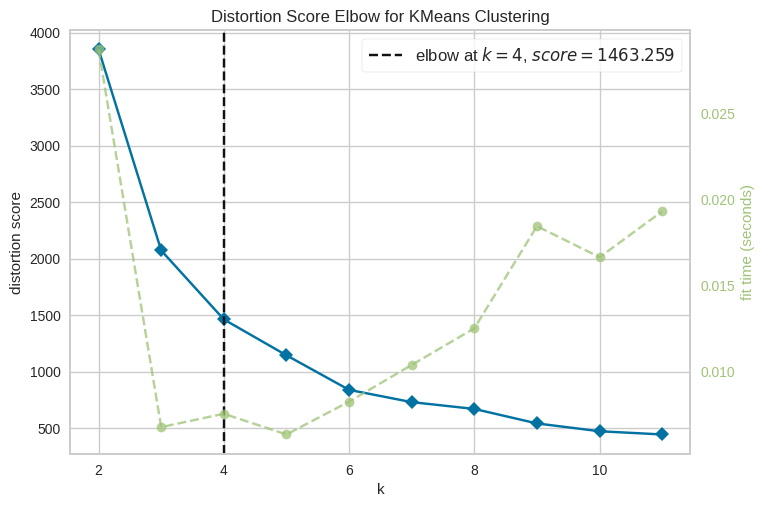

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
visualizer=KElbowVisualizer(estimator=KMeans(),k=(2,12),metrcic='silhouette',force_model=True)
visualizer.fit(df)
visualizer.show()